In [2]:
import pandas as pd

meta = pd.read_csv(r"C:\Users\Amol\OneDrive\Desktop\New folder\fsd50k\FSD50K.ground_truth\dev.csv")

print(meta.head())
print("Total samples:", len(meta))

   fname                                             labels  \
0  64760  Electric_guitar,Guitar,Plucked_string_instrume...   
1  16399  Electric_guitar,Guitar,Plucked_string_instrume...   
2  16401  Electric_guitar,Guitar,Plucked_string_instrume...   
3  16402  Electric_guitar,Guitar,Plucked_string_instrume...   
4  16404  Electric_guitar,Guitar,Plucked_string_instrume...   

                                            mids  split  
0  /m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf  train  
1  /m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf  train  
2  /m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf  train  
3  /m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf  train  
4  /m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf  train  
Total samples: 40966


In [3]:
print(meta['labels'].head())

0    Electric_guitar,Guitar,Plucked_string_instrume...
1    Electric_guitar,Guitar,Plucked_string_instrume...
2    Electric_guitar,Guitar,Plucked_string_instrume...
3    Electric_guitar,Guitar,Plucked_string_instrume...
4    Electric_guitar,Guitar,Plucked_string_instrume...
Name: labels, dtype: object


In [4]:
from collections import Counter

all_labels = []

for labels in meta['labels']:
    all_labels.extend(labels.split(","))

label_counts = Counter(all_labels)

# Top 20
for label, count in label_counts.most_common():
    print(label, count)

Music 12767
Musical_instrument 12763
Domestic_sounds_and_home_sounds 4711
Human_voice 4020
Animal 3275
Percussion 3152
Vehicle 2680
Wind_instrument_and_woodwind_instrument 2548
Bowed_string_instrument 1924
Plucked_string_instrument 1916
Guitar 1821
Wild_animals 1641
Speech 1469
Keyboard_(musical) 1428
Motor_vehicle_(road) 1399
Water 1360
Alarm 1280
Drum 1204
Bird 1189
Liquid 1125
Explosion 1122
Mechanisms 1073
Door 1056
Domestic_animals_and_pets 1054
Glass 974
Brass_instrument 949
Laughter 933
Engine 854
Respiratory_sounds 822
Bell 798
Human_group_actions 792
Tools 788
Piano 779
Dog 752
Snare_drum 741
Car 673
Cymbal 669
Rail_transport 637
Trumpet 581
Hands 573
Acoustic_guitar 538
Fart 533
Singing 523
Telephone 520
Livestock_and_farm_animals_and_working_animals 515
Electric_guitar 506
Bird_vocalization_and_bird_call_and_bird_song 502
Rain 500
Thunderstorm 469
Hi-hat 458
Thunder 455
Coin_(dropping) 437
Breathing 431
Bark 414
Shatter 414
Fireworks 402
Applause 400
Female_speech_and_woman_

In [5]:
TARGET_CLASSES = {
    "Scream": ["Screaming"],
    "Shout": ["Shout", "Yell"],
    "Crying": ["Crying_and_sobbing"],
    "Explosion": ["Explosion", "Fireworks"],
    "Gunshot": ["Gunshot_and_gunfire"],
    "Glass": ["Glass", "Shatter"],
    "Siren": ["Siren"],
    "Alarm": ["Alarm"]
}

In [6]:
def encode_labels(label_str):
    labels = label_str.split(",")
    
    output = []
    
    for key, variations in TARGET_CLASSES.items():
        found = any(any(v.lower() in l.lower() for v in variations) for l in labels)
        output.append(1 if found else 0)
    
    return output

In [7]:
meta['multi_label'] = meta['labels'].apply(encode_labels)

filtered_meta = meta[meta['multi_label'].apply(lambda x: sum(x) > 0)]

print("Filtered samples:", len(filtered_meta))

Filtered samples: 3909


In [8]:
class_counts = {k: 0 for k in TARGET_CLASSES.keys()}

for labels in filtered_meta['labels']:
    for key, variations in TARGET_CLASSES.items():
        if any(v.lower() in labels.lower() for v in variations):
            class_counts[key] += 1

print(class_counts)

{'Scream': 254, 'Shout': 216, 'Crying': 109, 'Explosion': 1122, 'Gunshot': 348, 'Glass': 974, 'Siren': 77, 'Alarm': 1280}


In [9]:
non_distress = meta[meta['multi_label'].apply(lambda x: sum(x) == 0)]

In [10]:
non_distress['primary_label'] = non_distress['labels'].apply(lambda x: x.split(",")[0])

C:\Users\Amol\AppData\Local\Temp\ipykernel_10180\757325170.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  non_distress['primary_label'] = non_distress['labels'].apply(lambda x: x.split(",")[0])


In [11]:
balanced_non_distress = []

samples_per_class = 50   # you can tune (30–100)

for label in non_distress['primary_label'].unique():
    subset = non_distress[non_distress['primary_label'] == label]
    
    sampled = subset.sample(
        n=min(len(subset), samples_per_class),
        random_state=42
    )
    
    balanced_non_distress.append(sampled)

balanced_non_distress = pd.concat(balanced_non_distress)

In [12]:
final_meta = pd.concat([filtered_meta, balanced_non_distress])

# Shuffle
final_meta = final_meta.sample(frac=1, random_state=42).reset_index(drop=True)

print("Final dataset size:", len(final_meta))

Final dataset size: 12568


In [13]:
print("Distress samples:", len(filtered_meta))
print("Non-distress samples:", len(balanced_non_distress))

Distress samples: 3909
Non-distress samples: 8659


In [14]:
save_path = r"C:\Users\Amol\OneDrive\Desktop\New folder\final_meta.csv"

final_meta.to_csv(save_path, index=False)

print("Dataset saved at:", save_path)

Dataset saved at: C:\Users\Amol\OneDrive\Desktop\New folder\final_meta.csv


In [15]:
class_counts = {k: 0 for k in TARGET_CLASSES.keys()}

for labels in final_meta['labels']:
    for key, variations in TARGET_CLASSES.items():
        if any(v.lower() in labels.lower() for v in variations):
            class_counts[key] += 1

print("=== Distress Class Counts ===")
for k, v in class_counts.items():
    print(f"{k}: {v}")

=== Distress Class Counts ===
Scream: 254
Shout: 216
Crying: 109
Explosion: 1122
Gunshot: 348
Glass: 974
Siren: 77
Alarm: 1280


In [16]:
label_lengths = final_meta['multi_label'].apply(sum)

print("=== Labels per sample ===")
print(label_lengths.value_counts())

=== Labels per sample ===
multi_label
0    8659
1    3440
2     467
3       2
Name: count, dtype: int64


In [17]:
final_meta['is_distress'] = final_meta['multi_label'].apply(lambda x: 1 if sum(x) > 0 else 0)

print("=== Distress vs Non-Distress ===")
print(final_meta['is_distress'].value_counts())

=== Distress vs Non-Distress ===
is_distress
0    8659
1    3909
Name: count, dtype: int64


In [18]:
from collections import Counter

non_distress_labels = []

for labels in final_meta[final_meta['is_distress'] == 0]['labels']:
    non_distress_labels.append(labels.split(",")[0])

counter = Counter(non_distress_labels)

print("=== Non-Distress Labels ===")
for k, v in counter.most_common():
    print(k, v)

=== Non-Distress Labels ===
Strum 50
Computer_keyboard 50
Dishes_and_pots_and_pans 50
Walk_and_footsteps 50
Printer 50
Fowl 50
Drum 50
Mallet_percussion 50
Crack 50
Run 50
Bell 50
Animal 50
Cupboard_open_or_close 50
Cricket 50
Fixed-wing_aircraft_and_airplane 50
Frying_(food) 50
Gong 50
Child_speech_and_kid_speaking 50
Crash_cymbal 50
Hi-hat 50
Whoosh_and_swoosh_and_swish 50
Car_passing_by 50
Splash_and_splatter 50
Packing_tape_and_duct_tape 50
Accordion 50
Skateboard 50
Mechanisms 50
Cowbell 50
Sneeze 50
Scratching_(performance_technique) 50
Wood 50
Keys_jangling 50
Applause 50
Domestic_sounds_and_home_sounds 50
Drill 50
Harp 50
Fart 50
Water_tap_and_faucet 50
Rattle 50
Boat_and_Water_vehicle 50
Bass_drum 50
Bicycle 50
Raindrop 50
Bird_vocalization_and_bird_call_and_bird_song 50
Chuckle_and_chortle 50
Tools 50
Screech 50
Burping_and_eructation 50
Bark 50
Traffic_noise_and_roadway_noise 50
Speech 50
Zipper_(clothing) 50
Typewriter 50
Finger_snapping 50
Wind_instrument_and_woodwind_inst

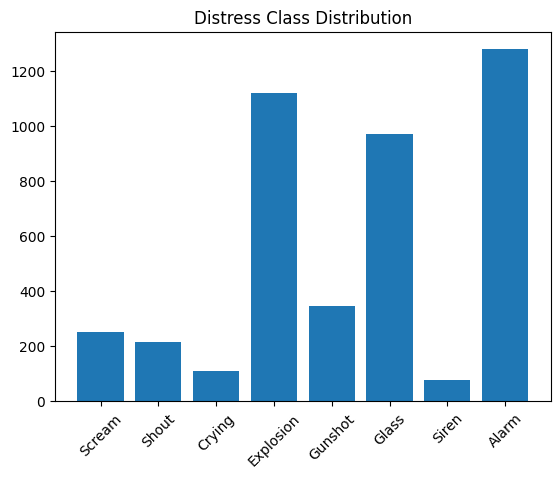

In [19]:
import matplotlib.pyplot as plt

plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45)
plt.title("Distress Class Distribution")
plt.show()